# 03bis LightGBM Deep Momentum Network

20 features (momentum + CPD, each with a lag-1 twin) -> LightGBM (L2) -> cross-sectional z-score -> `sigmoid(alpha* x z)` -> EMA (halflife=10d) -> CPD risk filter -> `positions.parquet` -> NB04.

Walk-forward: 16 annual folds 2011-2026, expanding windows since 2006, retrained every year.

In [1]:
from pathlib import Path
import sys, warnings
import numpy as np
import pandas as pd
import yaml
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
pd.set_option("display.float_format", "{:.4f}".format)

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.lgbm import (
    load_panel, load_cpd_features, build_feature_matrix, input_summary,
    build_feature_cols, TARGET_COL,
    walk_forward_splits, run_walk_forward, train_fold_lgb, compute_shap,
    smooth_positions, apply_cpd_filter, save_outputs,
)

with open(PROJECT_ROOT / "configs" / "default.yaml") as f:
    cfg = yaml.safe_load(f)

In [2]:
lcfg = cfg["lgbm"]
CPD_LBW = cfg["dmn"]["cpd_lbw"]
CPD_STRIDE = cfg["dmn"].get("cpd_stride", 1)
SEED = cfg["dmn"].get("seed", 42)

print(f"LightGBM : {lcfg['n_estimators']} trees | max_depth={lcfg['max_depth']} "
      f"| num_leaves={lcfg['num_leaves']}")
print(f"Position : EMA halflife={lcfg['position_halflife']}d | alpha in [0.1, {lcfg['alpha_max']}]")
print(f"Protocol : {'expanding' if lcfg['window_years'] is None else str(lcfg['window_years']) + 'y rolling'} "
      f"window, test years >= {lcfg['test_start']}")
print(f"CPD      : GP-based, lbw={CPD_LBW}, stride={CPD_STRIDE}")

LightGBM : 300 trees | max_depth=4 | num_leaves=15
Position : EMA halflife=10d | alpha in [0.1, 10]
Protocol : expanding window, test years >= 2011
CPD      : GP-based, lbw=21, stride=1


## 1. Data

Panel from NB01 (returns + momentum + region) merged with GP-based CPD scores (severity `nu`, location `gamma`) from NB02, at lookback window `cpd_lbw`. Target: `next_return` (J+1). Both the panel and the CPD features are cached to parquet after the first build.

In [3]:
panel = load_panel(cfg, PROJECT_ROOT)
cpd_features = load_cpd_features(cfg, PROJECT_ROOT, CPD_LBW, CPD_STRIDE)

feat = build_feature_matrix(panel, cpd_features, CPD_LBW)
feature_cols = build_feature_cols(CPD_LBW)

display(input_summary(feat, CPD_LBW))

,item,value
0,rows,"2,802,379"
1,tickers,"1,311"
2,date range,2006-02-01 -> 2026-05-05
3,features,20
4,model,LightGBM L2 + calibration alpha* Sharpe-net
5,target,next_return


## 2. Features -- 20 signals

| Group | N | |
|---|---|---|
| Momentum | 18 | `norm_ret` x5, `macd` x3 pairs, `ewma_vol` -- current + lag-1 |
| CPD (stock) | 2 | `cpd_nu_{lbw}_lag1` (severity) + `cpd_gamma_{lbw}_lag1` (location) -- GP changepoint kernel (Wood, Roberts & Zohren 2022) |

The lag-1 twins give LightGBM temporal dynamics without needing sequences (no LSTM).

## 3. Architecture

LightGBM L2/MSE, 300 trees, depth 4, L1+L2 -- suited to a weak daily-return signal.

Predictions are z-scored cross-sectionally within each date, then **alpha\*** is calibrated on net Sharpe (25bps) via `sigmoid(alpha x z)`. Alpha≈0.5 -> conservative positions | Alpha≈10 -> aggressive, near-binary positions.

In [4]:
display(pd.DataFrame([
    {"param": "n_estimators",      "value": str(lcfg["n_estimators"]),      "role": "Number of trees"},
    {"param": "learning_rate",     "value": str(lcfg["learning_rate"]),     "role": "Shrinkage -- slow, stable convergence"},
    {"param": "max_depth",         "value": str(lcfg["max_depth"]),         "role": "Max depth -- shallow trees, limits memorisation"},
    {"param": "min_child_samples", "value": str(lcfg["min_child_samples"]), "role": "Min obs/leaf -- avoids splitting on outliers"},
    {"param": "reg_alpha (L1)",    "value": str(lcfg["reg_alpha"]),         "role": "L1 penalty -- pushes useless weights to 0"},
    {"param": "reg_lambda (L2)",   "value": str(lcfg["reg_lambda"]),        "role": "L2 penalty -- shrinks large coefficients"},
    {"param": "EMA halflife",      "value": f"{lcfg['position_halflife']} days", "role": "Temporal smoothing of positions -- turnover control"},
]))

,param,value,role
0,n_estimators,300,Number of trees
1,learning_rate,0.05,"Shrinkage -- slow, stable convergence"
2,max_depth,4,"Max depth -- shallow trees, limits memorisation"
3,min_child_samples,20,Min obs/leaf -- avoids splitting on outliers
4,reg_alpha (L1),0.1,L1 penalty -- pushes useless weights to 0
5,reg_lambda (L2),0.1,L2 penalty -- shrinks large coefficients
6,EMA halflife,10 days,Temporal smoothing of positions -- turnover co...


## 4. Walk-forward -- 2011-2026

16 annual folds, expanding windows since 2006. The final `val_frac` (10%) of each fold's training window calibrates alpha*.

In [5]:
splits = walk_forward_splits(feat, test_start=lcfg["test_start"], window_years=lcfg["window_years"])

fold_rows = []
for i, sp in enumerate(splits, start=1):
    train_start = sp["train_start"].year if sp.get("train_start") else 2006
    train_end = sp["train_end"].year
    fold_rows.append({
        "fold": i,
        "train": f"{train_start} -> {train_end}",
        "test": sp["test_year"],
        "n_train_rows": feat.loc[feat["date"] <= sp["train_end"]].shape[0],
    })

display(pd.DataFrame(fold_rows))

# trains one LightGBM model per fold, calibrates alpha* on validation, predicts on the test year
positions, fold_metrics = run_walk_forward(feat, feature_cols=feature_cols, cfg=cfg, seed=SEED, verbose=False)

fold_display = fold_metrics[["test_year", "val_ic", "alpha_calibrated", "val_sharpe"]].copy()
fold_display = fold_display.rename(columns={
    "test_year": "test year",
    "val_ic": "IC (val)",
    "alpha_calibrated": "alpha* calibrated",
    "val_sharpe": "Sharpe gross (val)",
})
fold_display["alpha* calibrated"] = fold_display["alpha* calibrated"].astype(int)
fold_display["IC (val)"] = fold_display["IC (val)"].map("{:.4f}".format)
fold_display["Sharpe gross (val)"] = fold_display["Sharpe gross (val)"].map("{:+.3f}".format)

print("Results by fold")
display(fold_display)

,fold,train,test,n_train_rows
0,1,2006 -> 2010,2011,669975
1,2,2006 -> 2011,2012,811121
2,3,2006 -> 2012,2013,950003
3,4,2006 -> 2013,2014,1088214
4,5,2006 -> 2014,2015,1226684
5,6,2006 -> 2015,2016,1365805
6,7,2006 -> 2016,2017,1505873
7,8,2006 -> 2017,2018,1642545
8,9,2006 -> 2018,2019,1778963
9,10,2006 -> 2019,2020,1916509


Results by fold


,test year,IC (val),alpha* calibrated,Sharpe gross (val)
0,2011,0.0215,0,+0.898
1,2012,0.0480,0,-0.567
2,2013,0.0258,0,+0.549
3,2014,0.0281,1,+0.363
4,2015,-0.0067,0,+0.047
5,2016,0.0312,0,+0.256
6,2017,0.0263,0,+0.158
7,2018,0.0259,0,+0.629
8,2019,0.0253,0,-0.324
9,2020,0.0183,0,+0.161


## 5. Positions

1. **EMA** (halflife=10d) -- smooths positions, cuts turnover
2. **CPD filter** -- pulls toward 0.5 when a regime break is detected

`pos_filtered = 0.5 + (1 - strength * nu) * (pos - 0.5)`

In [6]:
positions_smooth = smooth_positions(positions, halflife=lcfg["position_halflife"])
positions_filtered = apply_cpd_filter(positions_smooth, feat, cpd_lbw=CPD_LBW, strength=lcfg["cpd_filter_strength"])

check = positions_smooth.merge(
    positions_filtered.rename(columns={"position": "pos_filtered"}),
    on=["date", "ticker"], how="inner",
)
frac_affected = ((check["pos_filtered"] - check["position"]).abs() > 0.01).mean()

print("Position smoothing and CPD filter")
print("Raw sigmoid std :", f"{positions['position'].std():.4f}")
print("After EMA std   :", f"{positions_smooth['position'].std():.4f}")
print("After CPD filter:", f"{frac_affected:.1%}", "positions adjusted")

Position smoothing and CPD filter
Raw sigmoid std : 0.0576
After EMA std   : 0.0275
After CPD filter: 28.1% positions adjusted


## 6. Out-of-sample performance

Equal-weighted portfolio, positions after EMA + CPD, returns **gross of transaction costs** -- the full net-of-cost analysis (with the vol-target framework and the LSTM variants) lives in NB04.

Out-of-sample performance, equal-weighted and gross of TC
Annualised return: 3.09%
Annualised vol   : 8.45%
Sharpe ratio     : +0.366
Max drawdown     : -20.75%
Hit rate         : 51.2%
Trading days     : 3,863


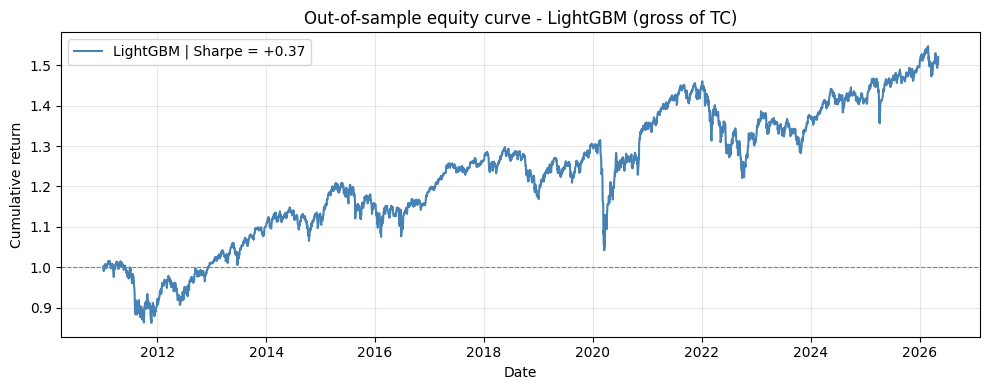

In [7]:
eval_df = positions_filtered.merge(
    feat[["date", "ticker", TARGET_COL]],
    on=["date", "ticker"], how="inner",
)
eval_df["strat_ret"] = eval_df["position"] * eval_df[TARGET_COL]

daily_ret = eval_df.groupby("date")["strat_ret"].mean().sort_index()
cum_ret = (1 + daily_ret).cumprod()

ann_ret = daily_ret.mean() * 252
ann_vol = daily_ret.std() * np.sqrt(252)
sharpe = ann_ret / ann_vol if ann_vol > 0 else float("nan")
max_dd = (cum_ret / cum_ret.cummax() - 1).min()
hit_rate = (eval_df["strat_ret"] > 0).mean()

print("Out-of-sample performance, equal-weighted and gross of TC")
print("Annualised return:", f"{ann_ret:.2%}")
print("Annualised vol   :", f"{ann_vol:.2%}")
print("Sharpe ratio     :", f"{sharpe:+.3f}")
print("Max drawdown     :", f"{max_dd:.2%}")
print("Hit rate         :", f"{hit_rate:.1%}")
print("Trading days     :", f"{daily_ret.shape[0]:,}")

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(cum_ret.index, cum_ret.values, color="steelblue", linewidth=1.5,
        label=f"LightGBM | Sharpe = {sharpe:+.2f}")
ax.axhline(1.0, color="gray", linestyle="--", linewidth=0.8)
ax.set_xlabel("Date")
ax.set_ylabel("Cumulative return")
ax.set_title("Out-of-sample equity curve - LightGBM (gross of TC)")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 7. Interpretability: SHAP

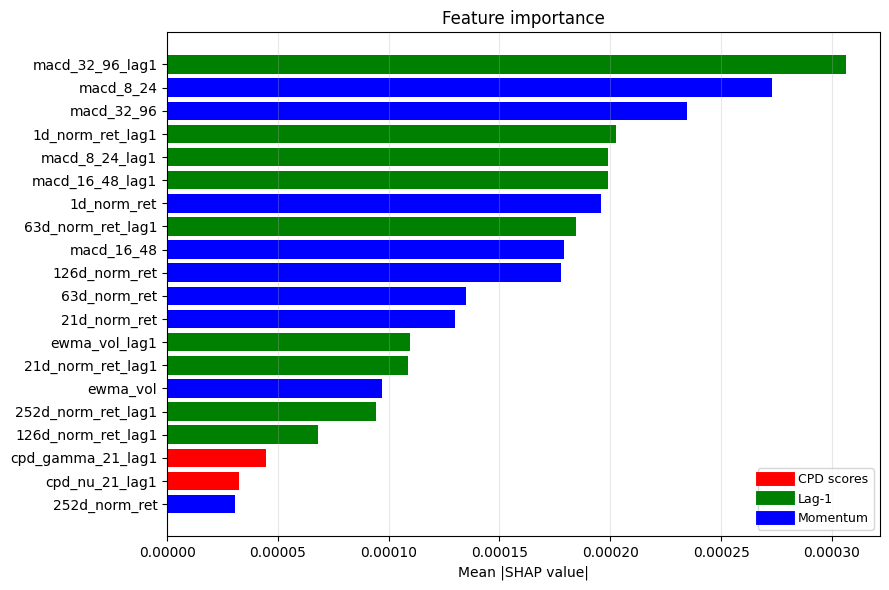

In [8]:
# retrain on the full panel to stabilise SHAP values
lgb_params = {
    "learning_rate": lcfg["learning_rate"],
    "max_depth": lcfg["max_depth"],
    "num_leaves": lcfg["num_leaves"],
    "min_child_samples": lcfg["min_child_samples"],
    "subsample": lcfg["subsample"],
    "subsample_freq": 1,
    "colsample_bytree": lcfg["colsample_bytree"],
    "reg_alpha": lcfg["reg_alpha"],
    "reg_lambda": lcfg["reg_lambda"],
    "n_jobs": -1,
    "verbose": -1,
}

X_all_df = feat.dropna(subset=feature_cols + [TARGET_COL])
X_all = X_all_df[feature_cols].fillna(0.0).to_numpy(dtype=np.float64)
y_all = X_all_df[TARGET_COL].to_numpy(dtype=np.float64)

n_val = max(1_000, int(len(X_all) * lcfg["val_frac"]))
model_shap, _, _ = train_fold_lgb(
    X_all[:-n_val],
    y_all[:-n_val],
    X_all[-n_val:],
    y_all[-n_val:],
    lgb_params=lgb_params,
    n_estimators=lcfg["n_estimators"],
    seed=SEED,
    alpha_max=lcfg["alpha_max"],
    position_halflife=lcfg["position_halflife"],
    transaction_cost=lcfg["transaction_cost"],
)

# Compute and Sort SHAP Values
shap_df = compute_shap(model_shap, feat, feature_cols, seed=SEED)
top = shap_df.head(25).sort_values("mean_abs_shap", ascending=True)

colors = []
for feature in top["feature"]:
    if "nu_" in feature or "gamma_" in feature:
        colors.append("red")
    elif "_lag1" in feature:
        colors.append("green")
    else:
        colors.append("blue")

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(top["feature"], top["mean_abs_shap"], color=colors)
ax.plot([], [], color="red", label="CPD scores", linewidth=10)
ax.plot([], [], color="green", label="Lag-1", linewidth=10)
ax.plot([], [], color="blue", label="Momentum", linewidth=10)
ax.legend(loc="lower right", fontsize=9); ax.grid(True, alpha=0.3, axis="x")
ax.set_xlabel("Mean |SHAP value|")
ax.set_title("Feature importance")
plt.tight_layout(); plt.show()

In [9]:
display(save_outputs(cfg, PROJECT_ROOT, positions_filtered, fold_metrics))

,output,rows,path
0,positions,"2,132,404",data/processed/stoxx600/positions.parquet
1,fold_metrics,16,data/processed/stoxx600/fold_metrics.parquet
